In [1]:
# ============================================
# CELL 1: Setup
# ============================================
!pip install -q rank_bm25 sentence-transformers faiss-cpu nltk matplotlib pandas

import numpy as np
import pandas as pd
import re
from typing import List, Dict, Tuple
from dataclasses import dataclass, field

import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder
import faiss

STOPWORDS = set(stopwords.words('english'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 72.9 MB/s eta 0:00:00


In [2]:
# ============================================
# CELL 2: Corpus + a labeled evaluation dataset (ground truth)
# In production this comes from human annotation or synthetic generation —
# here we hand-craft it so the lesson is fully self-contained and verifiable.
# ============================================

corpus = [
    "Our return policy allows customers to send back items within 30 days for a full refund.",          # 0
    "If you're unhappy with a purchase, you can request money back within a month of buying it.",        # 1
    "Items marked as final sale are not eligible for return or refund under any circumstances.",         # 2
    "Refunds are typically processed within 5-7 business days after the return is received.",            # 3
    "Machine learning models can automatically detect fraudulent transactions in real time.",             # 4
    "AI systems are increasingly used to flag suspicious financial activity as it happens.",               # 5
    "Employees can request remote work arrangements through the HR portal.",                              # 6
    "Remote work requests must be approved by a direct manager before taking effect.",                    # 7
    "Error code E-4021 indicates a payment gateway timeout. Restart the transaction to resolve it.",       # 8
    "Product SKU-88213-A is the wireless keyboard model, currently out of stock in the US warehouse.",     # 9
    "Invoice #INV-2024-11837 was issued on March 3rd for account holder J. Martinez.",                    # 10
    "The company's quarterly earnings report will be released next Thursday.",                            # 11
    "New office locations are opening in Austin and Denver next quarter.",                                # 12
]

# Ground truth: for each query, which doc_ids are relevant, with GRADED relevance
# (3 = highly relevant/directly answers, 2 = relevant, 1 = marginally relevant, absent = irrelevant)
eval_dataset = [
    {
        "query": "How do I get a refund for my order?",
        "relevance": {0: 3, 1: 2, 3: 2, 2: 1}   # doc 2 is only marginally relevant (mentions exceptions)
    },
    {
        "query": "How long does it take to get my money back?",
        "relevance": {3: 3, 0: 1}
    },
    {
        "query": "Can I work from home?",
        "relevance": {6: 3, 7: 2}
    },
    {
        "query": "What does error E-4021 mean?",
        "relevance": {8: 3}
    },
    {
        "query": "Is the wireless keyboard in stock?",
        "relevance": {9: 3}
    },
    {
        "query": "How does AI help detect fraud?",
        "relevance": {4: 3, 5: 3}
    },
]

print(f"Corpus size: {len(corpus)} documents")
print(f"Evaluation set: {len(eval_dataset)} labeled queries")

Corpus size: 13 documents
Evaluation set: 6 labeled queries


In [3]:
# ============================================
# CELL 3: Retrieval pipeline components (condensed from previous lessons)
# ============================================

def preprocess_text(text: str) -> List[str]:
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = word_tokenize(text)
    return [t for t in tokens if t not in STOPWORDS and len(t) > 1]


class SparseRetriever:
    def __init__(self, documents: List[str]):
        self.documents = documents
        self.bm25 = BM25Okapi([preprocess_text(d) for d in documents])

    def search(self, query: str, top_k: int = 10) -> List[int]:
        scores = self.bm25.get_scores(preprocess_text(query))
        ranked = np.argsort(scores)[::-1][:top_k]
        return [int(i) for i in ranked if scores[i] > 0]


class DenseRetriever:
    def __init__(self, documents: List[str], model_name: str = "all-MiniLM-L6-v2"):
        self.documents = documents
        self.model = SentenceTransformer(model_name)
        emb = self.model.encode(documents, show_progress_bar=False).astype("float32")
        faiss.normalize_L2(emb)
        self.index = faiss.IndexFlatIP(emb.shape[1])
        self.index.add(emb)

    def search(self, query: str, top_k: int = 10) -> List[int]:
        q = self.model.encode([query]).astype("float32")
        faiss.normalize_L2(q)
        _, idx = self.index.search(q, top_k)
        return [int(i) for i in idx[0] if i != -1]


def hybrid_rrf_search(sparse, dense, query: str, top_k: int = 10, candidate_k: int = 20, rrf_k: int = 60) -> List[int]:
    s_results = sparse.search(query, candidate_k)
    d_results = dense.search(query, candidate_k)
    s_ranks = {doc_id: r + 1 for r, doc_id in enumerate(s_results)}
    d_ranks = {doc_id: r + 1 for r, doc_id in enumerate(d_results)}
    all_ids = set(s_ranks) | set(d_ranks)
    scored = []
    for doc_id in all_ids:
        score = (1.0 / (rrf_k + s_ranks[doc_id]) if doc_id in s_ranks else 0.0) + \
                (1.0 / (rrf_k + d_ranks[doc_id]) if doc_id in d_ranks else 0.0)
        scored.append((doc_id, score))
    scored.sort(key=lambda x: x[1], reverse=True)
    return [doc_id for doc_id, _ in scored[:top_k]]


sparse_retriever = SparseRetriever(corpus)
dense_retriever = DenseRetriever(corpus)
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
print("Pipeline components ready.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Pipeline components ready.


In [4]:
# ============================================
# CELL 4: PRODUCTION EVALUATION METRICS LIBRARY
# Clean, reusable, well-documented implementations of
# Recall@K, Precision@K, MRR, and NDCG@K — from scratch (no black-box libs)
# so you fully understand every line.
# ============================================

def recall_at_k(retrieved_ids: List[int], relevance: Dict[int, int], k: int) -> float:
    """Fraction of ALL relevant docs found within top-k retrieved results."""
    relevant_ids = set(relevance.keys())
    if not relevant_ids:
        return 0.0
    retrieved_top_k = set(retrieved_ids[:k])
    found = relevant_ids & retrieved_top_k
    return len(found) / len(relevant_ids)


def precision_at_k(retrieved_ids: List[int], relevance: Dict[int, int], k: int) -> float:
    """Fraction of top-k retrieved results that are actually relevant."""
    if k == 0:
        return 0.0
    retrieved_top_k = retrieved_ids[:k]
    relevant_ids = set(relevance.keys())
    hits = sum(1 for doc_id in retrieved_top_k if doc_id in relevant_ids)
    return hits / k


def reciprocal_rank(retrieved_ids: List[int], relevance: Dict[int, int]) -> float:
    """1 / rank of the FIRST relevant document found. 0 if none found."""
    relevant_ids = set(relevance.keys())
    for rank, doc_id in enumerate(retrieved_ids, start=1):
        if doc_id in relevant_ids:
            return 1.0 / rank
    return 0.0


def dcg_at_k(retrieved_ids: List[int], relevance: Dict[int, int], k: int) -> float:
    """Discounted Cumulative Gain: sum of relevance scores, discounted by log2(rank+1)."""
    dcg = 0.0
    for rank, doc_id in enumerate(retrieved_ids[:k], start=1):
        rel = relevance.get(doc_id, 0)
        dcg += rel / np.log2(rank + 1)
    return dcg


def ndcg_at_k(retrieved_ids: List[int], relevance: Dict[int, int], k: int) -> float:
    """Normalized DCG: DCG divided by the best-possible (ideal) DCG."""
    actual_dcg = dcg_at_k(retrieved_ids, relevance, k)

    # Ideal ranking: sort relevant docs by relevance score, descending
    ideal_order = sorted(relevance.keys(), key=lambda d: relevance[d], reverse=True)
    ideal_dcg = dcg_at_k(ideal_order, relevance, k)

    if ideal_dcg == 0:
        return 0.0
    return actual_dcg / ideal_dcg


print("Metrics library loaded: recall_at_k, precision_at_k, reciprocal_rank, ndcg_at_k")

Metrics library loaded: recall_at_k, precision_at_k, reciprocal_rank, ndcg_at_k


In [5]:
# ============================================
# CELL 5: Sanity-check the metrics against the hand-worked example from Section 2.5
# (Always unit-test your metric implementations before trusting them!)
# ============================================

# From the lesson: relevance = {A:3, B:2, C:1}, retrieved = [X(irrelevant), A, C]
# Using doc_ids 0=X(irrelevant, not in relevance dict), 1=A, 2=C, 3=B(not retrieved)
test_relevance = {1: 3, 3: 2, 2: 1}   # doc 1=A(rel3), doc3=B(rel2), doc2=C(rel1)
test_retrieved = [0, 1, 2]             # X(irrelevant), A, C

test_ndcg = ndcg_at_k(test_retrieved, test_relevance, k=3)
test_recall = recall_at_k(test_retrieved, test_relevance, k=3)
test_rr = reciprocal_rank(test_retrieved, test_relevance)

print(f"NDCG@3:   {test_ndcg:.3f}   (expected ~0.502)")
print(f"Recall@3: {test_recall:.3f}  (expected ~0.667)")
print(f"RR:       {test_rr:.3f}     (expected 0.500)")
assert abs(test_ndcg - 0.502) < 0.01, "NDCG implementation mismatch!"
print("\n✓ Metric implementations verified against hand-worked example.")

NDCG@3:   0.502   (expected ~0.502)
Recall@3: 0.667  (expected ~0.667)
RR:       0.500     (expected 0.500)

✓ Metric implementations verified against hand-worked example.


In [6]:
# ============================================
# CELL 6: FULL EVALUATION HARNESS
# Runs every query in eval_dataset through THREE retrieval configurations
# (sparse-only, dense-only, hybrid) and reports averaged metrics —
# this is exactly the kind of harness you'd build to justify architecture decisions.
# ============================================

@dataclass
class EvalResult:
    system_name: str
    per_query_metrics: List[Dict] = field(default_factory=list)

    def add(self, query: str, retrieved: List[int], relevance: Dict[int, int], k: int):
        self.per_query_metrics.append({
            "query": query,
            "recall@k": recall_at_k(retrieved, relevance, k),
            "precision@k": precision_at_k(retrieved, relevance, k),
            "rr": reciprocal_rank(retrieved, relevance),
            "ndcg@k": ndcg_at_k(retrieved, relevance, k),
        })

    def summary(self) -> Dict:
        df = pd.DataFrame(self.per_query_metrics)
        return {
            "system": self.system_name,
            "mean_recall@k": df["recall@k"].mean(),
            "mean_precision@k": df["precision@k"].mean(),
            "MRR": df["rr"].mean(),
            "mean_ndcg@k": df["ndcg@k"].mean(),
        }


def evaluate_system(name: str, retrieve_fn, eval_dataset: List[Dict], k: int = 5) -> EvalResult:
    result = EvalResult(system_name=name)
    for item in eval_dataset:
        retrieved = retrieve_fn(item["query"], k)
        result.add(item["query"], retrieved, item["relevance"], k)
    return result


K = 5

sparse_only = evaluate_system(
    "Sparse (BM25) only",
    lambda q, k: sparse_retriever.search(q, k),
    eval_dataset, K
)

dense_only = evaluate_system(
    "Dense only",
    lambda q, k: dense_retriever.search(q, k),
    eval_dataset, K
)

hybrid_only = evaluate_system(
    "Hybrid (RRF)",
    lambda q, k: hybrid_rrf_search(sparse_retriever, dense_retriever, q, top_k=k),
    eval_dataset, K
)

def rerank_pipeline(query: str, k: int) -> List[int]:
    candidates = hybrid_rrf_search(sparse_retriever, dense_retriever, query, top_k=15)
    pairs = [[query, corpus[doc_id]] for doc_id in candidates]
    scores = reranker.predict(pairs, show_progress_bar=False)
    ranked = [doc_id for _, doc_id in sorted(zip(scores, candidates), reverse=True)]
    return ranked[:k]

hybrid_reranked = evaluate_system("Hybrid + Reranking", rerank_pipeline, eval_dataset, K)

summary_df = pd.DataFrame([
    sparse_only.summary(),
    dense_only.summary(),
    hybrid_only.summary(),
    hybrid_reranked.summary(),
])
print(summary_df.round(3).to_string(index=False))

            system  mean_recall@k  mean_precision@k   MRR  mean_ndcg@k
Sparse (BM25) only          0.833               0.3 0.917        0.780
        Dense only          1.000               0.4 1.000        0.983
      Hybrid (RRF)          1.000               0.4 0.917        0.925
Hybrid + Reranking          1.000               0.4 0.917        0.930


In [7]:
# ============================================
# CELL 7: Per-query breakdown — catching what averages hide (Pitfall #5)
# ============================================

per_query_comparison = []
for item in eval_dataset:
    row = {"query": item["query"][:40]}
    for name, retrieve_fn in [
        ("sparse_ndcg", lambda q, k: sparse_retriever.search(q, k)),
        ("dense_ndcg", lambda q, k: dense_retriever.search(q, k)),
        ("hybrid_ndcg", lambda q, k: hybrid_rrf_search(sparse_retriever, dense_retriever, q, top_k=k)),
        ("reranked_ndcg", rerank_pipeline),
    ]:
        retrieved = retrieve_fn(item["query"], K)
        row[name] = round(ndcg_at_k(retrieved, item["relevance"], K), 3)
    per_query_comparison.append(row)

per_query_df = pd.DataFrame(per_query_comparison)
print(per_query_df.to_string(index=False))
print("\n>> Notice: the exact-ID query ('error E-4021', 'wireless keyboard stock')")
print(">> likely favors sparse-heavy methods, while conceptual queries favor dense/hybrid.")
print(">> This is EXACTLY the per-query-type analysis averages hide (Pitfall #5).")

                                   query  sparse_ndcg  dense_ndcg  hybrid_ndcg  reranked_ndcg
     How do I get a refund for my order?        0.508       0.935        0.965          0.923
How long does it take to get my money ba        0.174       0.964        0.587          0.659
                   Can I work from home?        1.000       1.000        1.000          1.000
            What does error E-4021 mean?        1.000       1.000        1.000          1.000
      Is the wireless keyboard in stock?        1.000       1.000        1.000          1.000
          How does AI help detect fraud?        1.000       1.000        1.000          1.000

>> Notice: the exact-ID query ('error E-4021', 'wireless keyboard stock')
>> likely favors sparse-heavy methods, while conceptual queries favor dense/hybrid.
>> This is EXACTLY the per-query-type analysis averages hide (Pitfall #5).


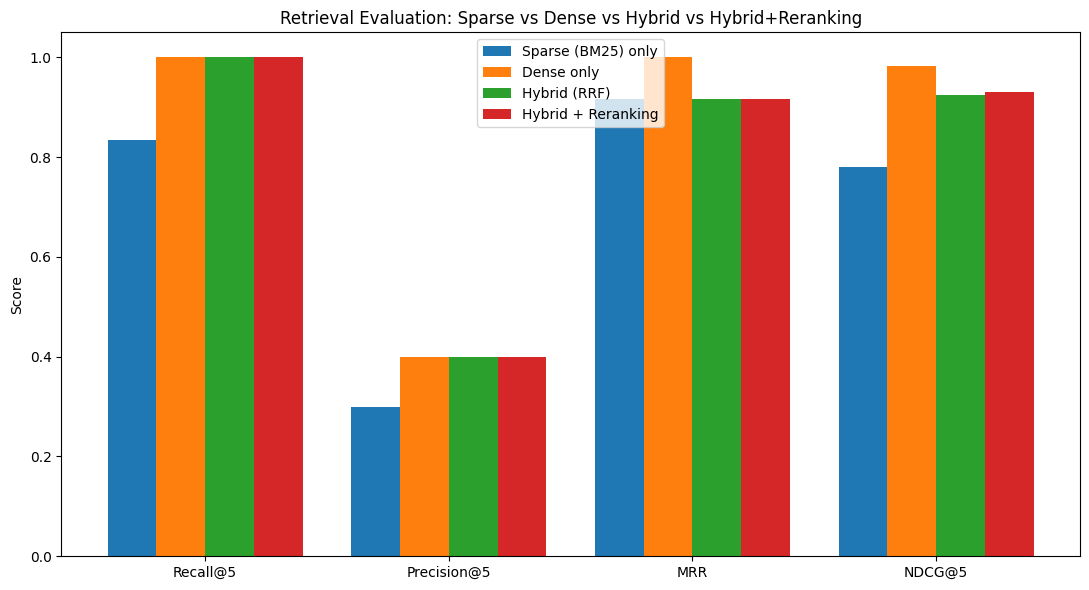

This chart is exactly what you'd present to justify a production architecture decision.


In [8]:
# ============================================
# CELL 8: Visualization — compare all 4 systems across all 4 metrics
# ============================================

import matplotlib.pyplot as plt

metrics_to_plot = ["mean_recall@k", "mean_precision@k", "MRR", "mean_ndcg@k"]
systems = summary_df["system"].tolist()

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(metrics_to_plot))
width = 0.2

for i, system in enumerate(systems):
    values = [summary_df.loc[summary_df["system"] == system, m].values[0] for m in metrics_to_plot]
    ax.bar(x + i * width, values, width, label=system)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(["Recall@5", "Precision@5", "MRR", "NDCG@5"])
ax.set_ylabel("Score")
ax.set_title("Retrieval Evaluation: Sparse vs Dense vs Hybrid vs Hybrid+Reranking")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print("This chart is exactly what you'd present to justify a production architecture decision.")

# **Evaluate at multiple K values**

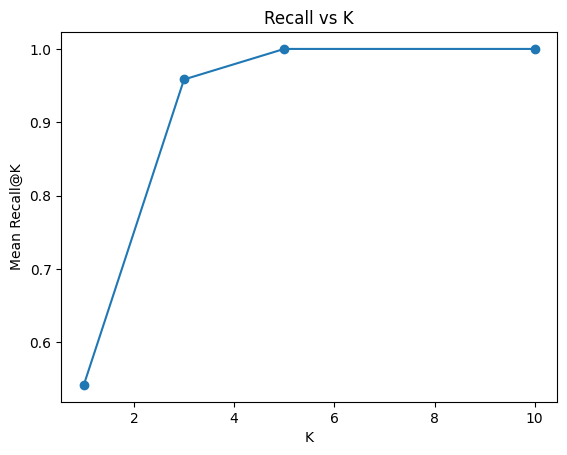

In [9]:
recall_by_k = []
for k_val in [1, 3, 5, 10]:
    result = evaluate_system(f"Hybrid@{k_val}",
                               lambda q, k: hybrid_rrf_search(sparse_retriever, dense_retriever, q, top_k=k),
                               eval_dataset, k_val)
    recall_by_k.append(result.summary()["mean_recall@k"])

plt.plot([1, 3, 5, 10], recall_by_k, 'o-')
plt.xlabel("K"); plt.ylabel("Mean Recall@K"); plt.title("Recall vs K")
plt.show()

You should see a monotonically non-decreasing curve — Recall@K can never decrease as K increases, because a larger top-K window can only include everything a smaller window included, plus potentially more. The curve typically rises steeply at first (each additional slot has a good chance of catching a relevant doc) then flattens out once most/all relevant docs have already been found — this plateau point is a useful signal for choosing how large your Stage-1 candidate pool needs to be.

# **Build a statistical significance sanity check**

In [10]:
comparison = []
for item in eval_dataset:
    hybrid_retrieved = hybrid_rrf_search(sparse_retriever, dense_retriever, item["query"], top_k=K)
    reranked_retrieved = rerank_pipeline(item["query"], K)
    h_ndcg = ndcg_at_k(hybrid_retrieved, item["relevance"], K)
    r_ndcg = ndcg_at_k(reranked_retrieved, item["relevance"], K)
    verdict = "reranking better" if r_ndcg > h_ndcg else ("hybrid better" if h_ndcg > r_ndcg else "tie")
    comparison.append({"query": item["query"][:40], "hybrid_ndcg": round(h_ndcg,3),
                        "reranked_ndcg": round(r_ndcg,3), "verdict": verdict})

print(pd.DataFrame(comparison).to_string(index=False))

                                   query  hybrid_ndcg  reranked_ndcg          verdict
     How do I get a refund for my order?        0.965          0.923    hybrid better
How long does it take to get my money ba        0.587          0.659 reranking better
                   Can I work from home?        1.000          1.000              tie
            What does error E-4021 mean?        1.000          1.000              tie
      Is the wireless keyboard in stock?        1.000          1.000              tie
          How does AI help detect fraud?        1.000          1.000              tie


# **Diagnose a "high recall, low NDCG" scenario**

In [11]:
# All 3 relevant docs found, but poorly ordered (least relevant one is at rank 1)
relevance = {5: 3, 6: 2, 7: 1}          # true best doc is 5, worst relevant is 7
retrieved = [7, 6, 5, 99, 100]          # found all 3, but in REVERSE relevance order

print("Recall@5:", recall_at_k(retrieved, relevance, 5))   # 1.0 — all relevant docs found
print("NDCG@5:  ", round(ndcg_at_k(retrieved, relevance, 5), 3))  # well below 1.0

Recall@5: 1.0
NDCG@5:   0.79
